

**Business Problem Statement :**  The global restaurant industry is highly competitive, with thousands of establishments offering diverse cuisines, price ranges, and service options. Customers often struggle to choose the right restaurant, and businesses face challenges in improving their visibility and attracting new patrons. For example, a global brand like McDonald’s operates in over 100 countries and must adapt its menu, pricing, and customer experience to local tastes while maintaining high ratings across regions.

With access to a comprehensive dataset containing restaurant details from around the world—including location, cuisines, cost, ratings, votes, and service features—there is an opportunity to leverage data-driven insights for strategic decision-making.

The objective is to build a predictive model that accurately estimates a restaurant's rating based on its attributes. This will involve:

  1.Identifying key factors that most strongly influence customer ratings across different regions.
  2.Analyzing patterns and trends in global dining preferences.
  3.Providing actionable recommendations to restaurants on how to improve their ratings and attract more customers.

By achieving this, the platform can deliver more accurate recommendations to users, help restaurants tailor their offerings to market demand, and ultimately improve customer satisfaction and business performance on a global scale.


In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
df = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE AND  GEN-AI/INTERNSHIPS/Cognifiz-Internship (ML)/Dataset .csv')
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [95]:
columns = len(df.columns)
print(f"Number of columns: {columns}")

Number of columns: 21


In [96]:
rows = len(df)
print((f"Numer of rows:  {rows}"))

Numer of rows:  9551


In [97]:
missing_values = df.isnull().sum()
print(f"Missing values:\n {missing_values}")

Missing values:
 Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


There are 9 missing values in column 'Cuisines'.

In [98]:
df['Cuisines'].dtype

dtype('O')

In [99]:
df['Cuisines'].fillna('Unknown', inplace =True)

/tmp/ipython-input-221338478.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cuisines'].fillna('Unknown', inplace =True)


In [100]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


## UNIVARIATE ANALYSYS

**DISCRIPTIVE ANALYSIS**

In [101]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,NaN,NaN,NaN,9051128.349178,8791521.282104,53.0,301962.5,6004089.0,18352291.5,18500652.0
Restaurant Name,9551,7446,Cafe Coffee Day,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,9551.0,NaN,NaN,NaN,18.365616,56.750546,1.0,1.0,1.0,1.0,216.0
City,9551,141,New Delhi,5473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,9551,8918,"Dilli Haat, INA, New Delhi",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,9551,1208,Connaught Place,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality Verbose,9551,1265,"Connaught Place, New Delhi",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,9551.0,NaN,NaN,NaN,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,NaN,NaN,NaN,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.97698
Cuisines,9551,1826,North Indian,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN




1. Geographic Focus and Market Concentration

The dataset is heavily concentrated in India, specifically in New Delhi. This is evident from:

  * Country Code: A vast majority of the entries likely correspond to India's country code.

  * City: "New Delhi" is the most frequent city by a large margin (5,473 times).

  * Currency: "Indian Rupees(Rs.)" is the dominant currency.

This concentration suggests the dataset is ideal for a detailed market analysis of the food and beverage industry in New Delhi, but less suitable for a broad, global market study without additional data. It's a goldmine for understanding local trends, competition, and customer behavior within this specific city.

2. Market Diversity and Competition

The market is diverse yet competitive, particularly in certain areas and for specific cuisines.

  * Restaurant Name: The presence of franchise names like "Cafe Coffee Day" (83 locations) shows that chain restaurants have a significant footprint.

  * Locality: "Connaught Place" is a popular locality, indicating it's a hub for restaurants and a highly competitive area.

  * Cuisines: "North Indian" is the most popular cuisine, suggesting a high supply of these restaurants. This could be a saturation point for new businesses or a reflection of high demand.

3. Pricing and Affordability

The pricing structure shows a wide range, but most restaurants are on the affordable side.

  * Average Cost for two: The median cost of 400 Rupees is a much better indicator than the mean (1,199). The low median and large number of restaurants in the lower Price range categories (1 and 2) suggest that the market is dominated by budget-friendly and mid-range dining options.

  * Outliers: The high max value for Average Cost for two (800,000) is likely a data error or a very rare, ultra-high-end restaurant. It should be investigated or treated as an outlier in any analysis.

4. Service Offerings and Customer Behavior

The data on services reveals key customer preferences and technological adoption.

  * Table Booking & Online Delivery: The high frequency of "No" for both Has Table booking and Has Online delivery indicates that a significant portion of the restaurants operate on a traditional walk-in model. This could be due to small business sizes, low tech adoption, or a preference for offline dining in this market.

  * Online Ordering: The Is delivering now and Switch to order menu columns suggest that real-time delivery and online menus are not widely adopted or were not active at the time of data collection.



In [102]:
numerical_columns = ['Restaurant ID',  'Country Code', 'Longitude', 'Latitude','Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
print(df[numerical_columns].describe())

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

In [103]:
# Exploring the distribution of the "Country Code"
print(df['Country Code'].value_counts())

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


In [104]:
# Exploring the distributioin of the "City"
print(df['City'].value_counts())

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64


In [105]:
# Exploring the distribution of the "Cuisines"
print(df['Cuisines'].value_counts())

Cuisines
North Indian                                                      936
North Indian, Chinese                                             511
Fast Food                                                         354
Chinese                                                           354
North Indian, Mughlai                                             334
                                                                 ... 
North Indian, Continental, Chinese, Italian, Mexican                1
North Indian, Continental, Chinese, Mexican, Italian, Desserts      1
Southern, Cajun, Soul Food                                          1
Continental, Mexican, North Indian, Chinese                         1
Italian, Mexican, American, Mediterranean                           1
Name: count, Length: 1826, dtype: int64


In [106]:
 # Identifying the top 10 cityes with highest number of restaurents
print(df['City'].value_counts().nlargest(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [107]:
# Identifying  the top 10 'Cuisines'
print(df['Cuisines'].value_counts().nlargest(10))

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [108]:
#spliting Cuisine column into individual Cuisines
cuisines = df['Cuisines'].str.split(',').explode()

In [109]:
#count of top 10 Cuisines after spliting
print(cuisines.value_counts().nlargest(10))

Cuisines
North Indian     2992
 Chinese         1880
 Fast Food       1314
 North Indian     968
Chinese           855
 Mughlai          780
Fast Food         672
Bakery            621
Cafe              617
 Italian          530
Name: count, dtype: int64


In [110]:
# calculatiing the number of restaurents in each city
city_count = df['City'].value_counts()
print(city_count)

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64


In [111]:
# Calculating the number of restaurents in each country
country_count = df['Country Code'].value_counts()
print(country_count)

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


In [112]:
#calculating the percentage of restaurents that offers table booking
table_booking_percentage = (df['Has Table booking'] == 'Yes').sum() / len(df)*100
print(f"precentage of restaurent that offers table booking: {table_booking_percentage:.2f}%")

precentage of restaurent that offers table booking: 12.12%


In [113]:
#calculating the percentage of restaurants thet offers online delivery
online_delivery_percentage = (df["Has Online delivery"]== 'Yes').sum() / len(df)*100
print(f"percentage of restaurants that offers Online delivery: {online_delivery_percentage:.2f}%")

percentage of restaurants that offers Online delivery: 25.66%


In [114]:
print(df['Price range'].value_counts())

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [115]:
most_common_price_range = df['Price range'].mode().values[0]
print(f"most common price range is: {most_common_price_range}")

most common price range is: 1


**VISUAL ANALYSIS**

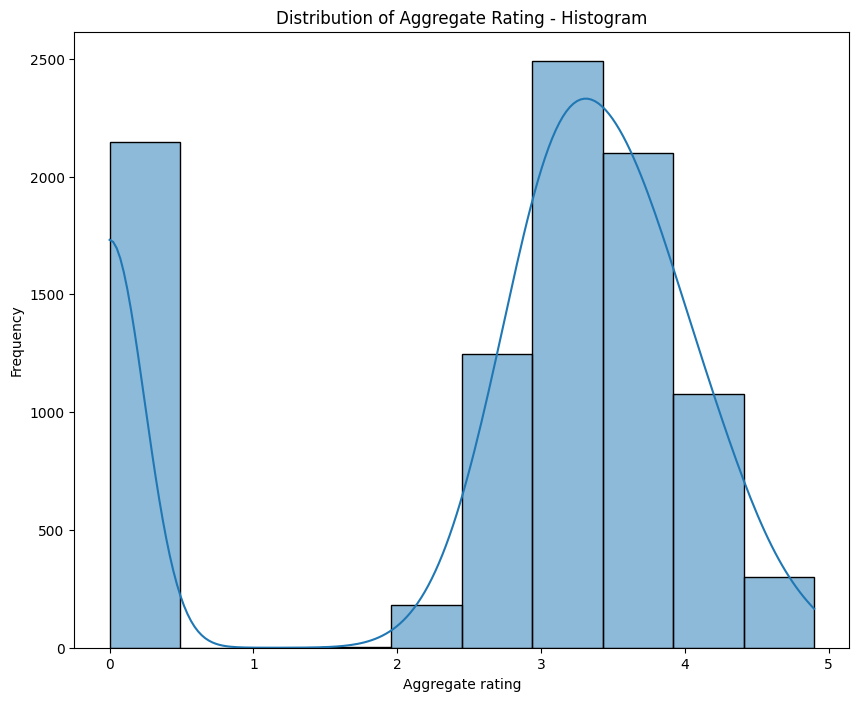

In [116]:
# Ploting the Histogram PLOT
plt.figure(figsize = (10,8))
sns.histplot(df['Aggregate rating'], bins=10, kde =True)
plt.title('Distribution of Aggregate Rating - Histogram')
plt.xlabel('Aggregate rating')
plt.ylabel('Frequency')
plt.show()

In [117]:
print('skewness:', df['Aggregate rating'].skew())

skewness: -0.9541304733200109


The 'Aggregated rating' is -0.95 which is negative skewed(left skewed) data.

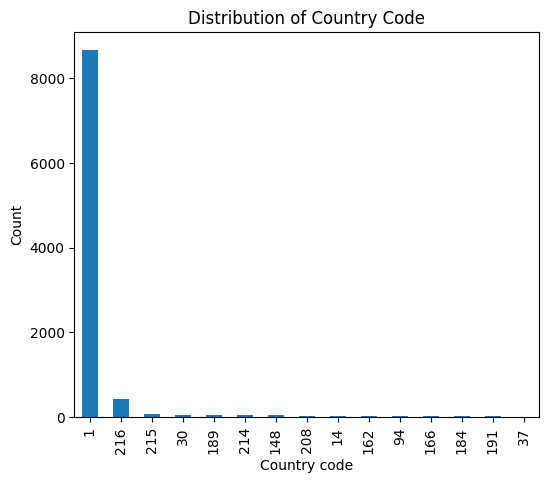

In [118]:
# PLOT for distribution of the Country code
plt.figure(figsize =(6,5))
df['Country Code'].value_counts().plot(kind = 'bar')
plt.title('Distribution of Country Code')
plt.xlabel('Country code')
plt.ylabel('Count')
plt.show()

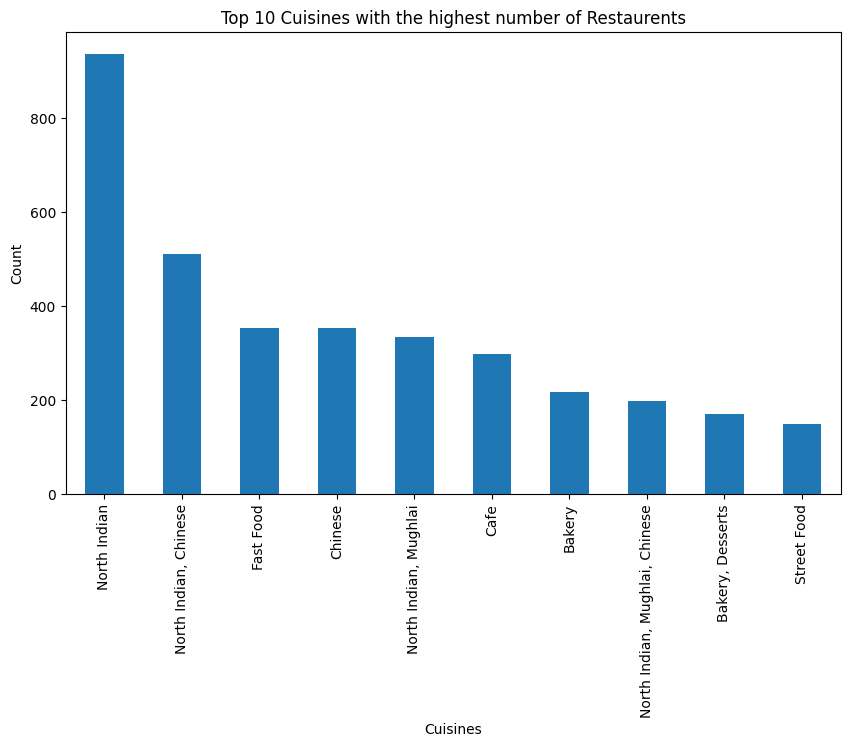

In [119]:
# PLOT for distribution of the Cuisines
plt.figure(figsize = (10, 6))
df['Cuisines'].value_counts().nlargest(10).plot(kind = 'bar')
plt.title('Top 10 Cuisines with the highest number of Restaurents')
plt.xlabel('Cuisines')
plt.ylabel('Count')
plt.show()

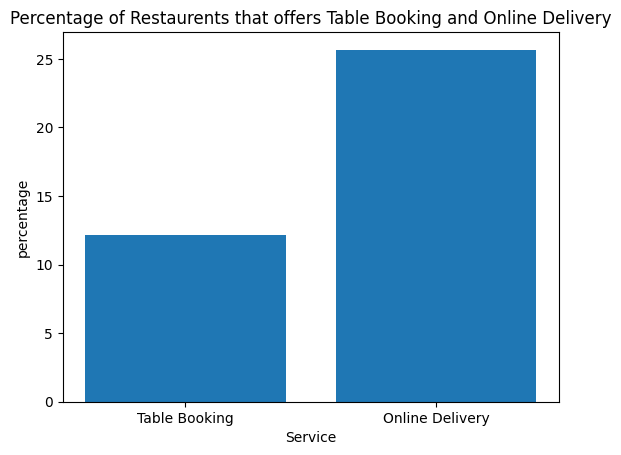

In [120]:
# Creating the bar plot
plt.bar(['Table Booking', 'Online Delivery'], [table_booking_percentage, online_delivery_percentage])
plt.xlabel('Service')
plt.ylabel('percentage')
plt.title('Percentage of Restaurents that offers Table Booking and Online Delivery')
plt.show()

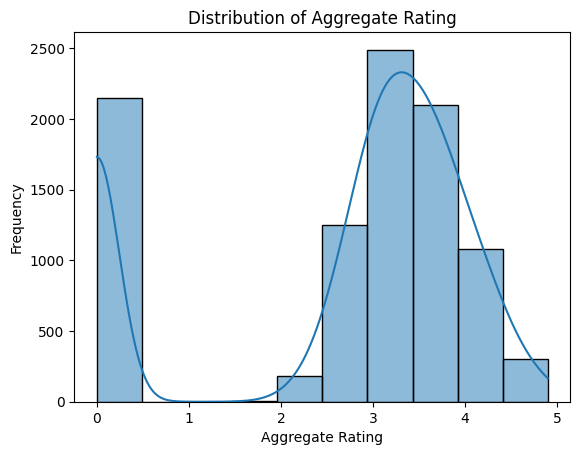

In [121]:

#Visualizing the distribution
sns.histplot(df['Aggregate rating'], bins = 10, kde=True)
plt.title('Distribution of Aggregate Rating')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

In [122]:
import folium

m = folium.Map(locaation = [df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=4)

for index, row in df.iterrows():
    folium.Marker([row['Latitude'], row['Longitude']], popup = row['Restaurant Name']).add_to(m)

m.save('restaurent_map_view.html')

## BI-Variate Analysis
**DISCRIPTIVE ANALYSYS**

In [123]:
df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
...,...
New Delhi,2.438845
Montville,2.400000
Mc Millan,2.400000


In [124]:
# Calculating the average rating for each city
city_ratings = df.groupby('City')['Aggregate rating'].mean()
print(city_ratings)

City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64


In [125]:
# Calculating  the average ratings of Country
country_rating = df.groupby('Country Code')['Aggregate rating'].mean()
print(country_rating)

Country Code
1      2.523324
14     3.658333
30     3.763333
37     3.575000
94     4.295238
148    4.262500
162    4.468182
166    4.060000
184    3.575000
189    4.210000
191    3.870000
208    4.300000
214    4.233333
215    4.087500
216    4.004378
Name: Aggregate rating, dtype: float64


In [126]:
df.groupby('Country Code')['Aggregate rating'].mean().sort_values(ascending = False)

,Aggregate rating
Country Code,
162,4.468182
208,4.300000
94,4.295238
148,4.262500
214,4.233333
189,4.210000
215,4.087500
166,4.060000
216,4.004378


In [127]:
from scipy.spatial import distance

# calculating the centroid of all the restarunt location
centroid = (df['Latitude'].mean(), df['Longitude'].mean())

#calculating distance between each restaurant and the centroid
df['Distance'] = df.apply(lambda row: distance.euclidean((row['Latitude'], row['Longitude']), centroid), axis=1)

#Calculating the correlation between distance and rating
correlation = df['Distance'].corr(df['Aggregate rating'])
print(correlation)

0.17440061739910626


In [128]:
# Calculate the average rating of restaurants with table booking
table_booking_avg_rating = df[df['Has Table booking'] == 'Yes'] ['Aggregate rating'].mean()
print(f"Average rating of restaurents with table booking: {table_booking_avg_rating:.2f}")

Average rating of restaurents with table booking: 3.44


In [129]:
#calculating the average rating of restaurantes without table booking
without_table_booking_avg_rating = df[df['Has Table booking'] == 'No'] ['Aggregate rating'].mean()
print(f"Averager rating of restaurants without table booking: {without_table_booking_avg_rating:.2f}")

Averager rating of restaurants without table booking: 2.56


In [130]:
online_delivery_percentage = df.groupby('Price range') ['Has Online delivery'].apply(lambda x: (x == 'Yes').sum() / len(x)*100)
print(online_delivery_percentage)

Price range
1    15.774077
2    41.310633
3    29.190341
4     9.044369
Name: Has Online delivery, dtype: float64


In [131]:
average_ratings= df.groupby('Price range')['Aggregate rating'].mean()
print(average_ratings)

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


In [132]:
avg_ratings = df.groupby(['Rating color', 'Price range']) ['Aggregate rating'].mean().reset_index()

In [133]:
# sort the average rating in decending order
agv_ratings = avg_ratings.sort_values('Aggregate rating', ascending = False)
print(avg_ratings)

   Rating color  Price range  Aggregate rating
0    Dark Green            1          4.668750
1    Dark Green            2          4.627536
2    Dark Green            3          4.646032
3    Dark Green            4          4.709459
4         Green            1          4.157639
5         Green            2          4.159385
6         Green            3          4.169231
7         Green            4          4.188144
8        Orange            1          3.040464
9        Orange            2          3.048491
10       Orange            3          3.097764
11       Orange            4          3.162376
12          Red            1          2.293548
13          Red            2          2.300000
14          Red            3          2.305000
15          Red            4          2.283333
16        White            1          0.000000
17        White            2          0.000000
18        White            3          0.000000
19        White            4          0.000000
20       Yell

In [134]:
# get the  row with the highest average rating
best_color = avg_ratings.iloc[0]

In [135]:
print('The color with the highest average rating is: ', best_color['Rating color'])

The color with the highest average rating is:  Dark Green


**VISUAL ANALYSIS**

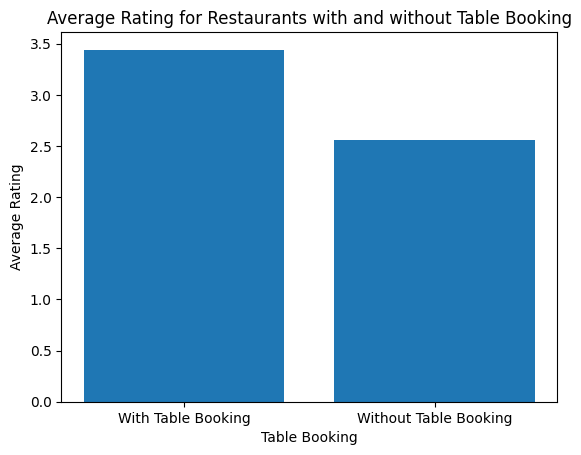

In [136]:
# Ploting the bar plot
plt.bar(['With Table Booking', 'Without Table Booking'], [table_booking_avg_rating, without_table_booking_avg_rating])
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')
plt.title('Average Rating for Restaurants with and without Table Booking')
plt.show()

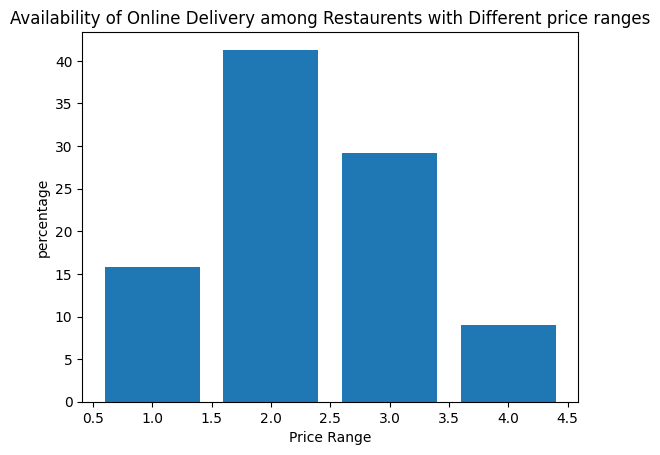

In [137]:
# creating a bar plot
plt.bar(online_delivery_percentage.index, online_delivery_percentage.values)
plt.xlabel('Price Range')
plt.ylabel('percentage')
plt.title('Availability of Online Delivery among Restaurents with Different price ranges')
plt.show()

##  Multivariate Analysys
**Discriptive Analysis**

In [138]:
numerical_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Distance']

In [139]:
correlation_matrix = df[numerical_cols].corr()

In [140]:
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                      Average Cost for two  Price range  Aggregate rating  \
Average Cost for two              1.000000     0.075083          0.051792   
Price range                       0.075083     1.000000          0.437944   
Aggregate rating                  0.051792     0.437944          1.000000   
Votes                             0.067783     0.309444          0.313691   
Distance                          0.022558     0.140035          0.174401   

                         Votes  Distance  
Average Cost for two  0.067783  0.022558  
Price range           0.309444  0.140035  
Aggregate rating      0.313691  0.174401  
Votes                 1.000000  0.107424  
Distance              0.107424  1.000000  


In [141]:
crosstab_result = pd.crosstab(df['City'], df['Has Table booking'])
print("Crosstab:")
print(crosstab_result)

Crosstab:
Has Table booking  No  Yes
City                      
Abu Dhabi          14    6
Agra               20    0
Ahmedabad          21    0
Albany             20    0
Allahabad          20    0
...                ..  ...
Weirton             1    0
Wellington City    20    0
Winchester Bay      1    0
Yorkton             1    0
��stanbul          14    0

[141 rows x 2 columns]


**VISUAL ANALYSIS**

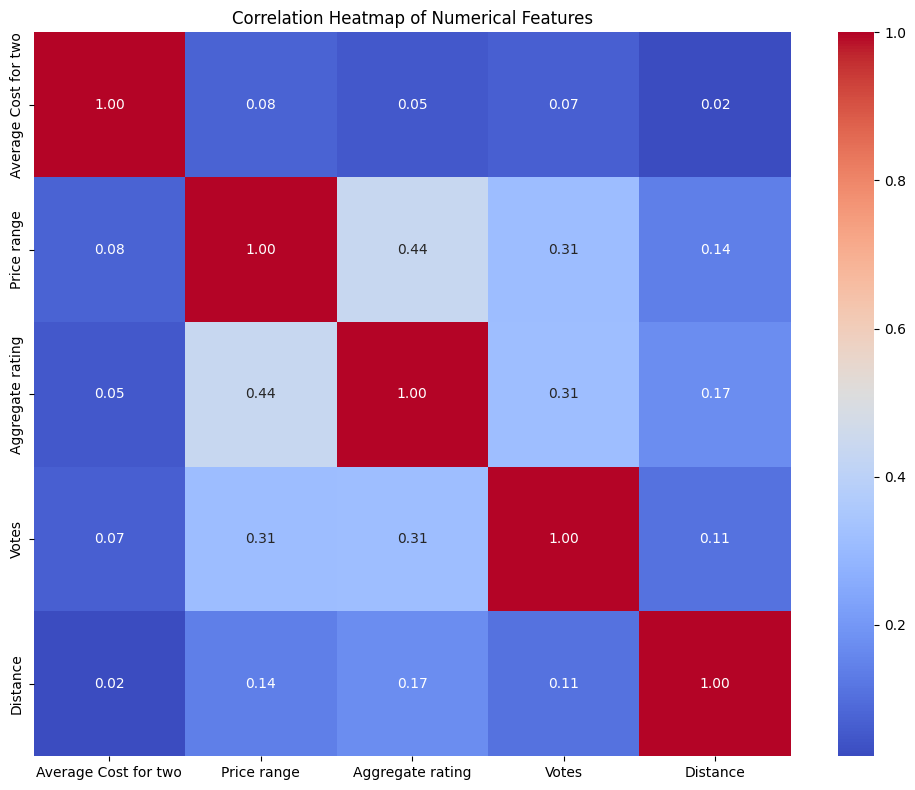

In [142]:
# Create a correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

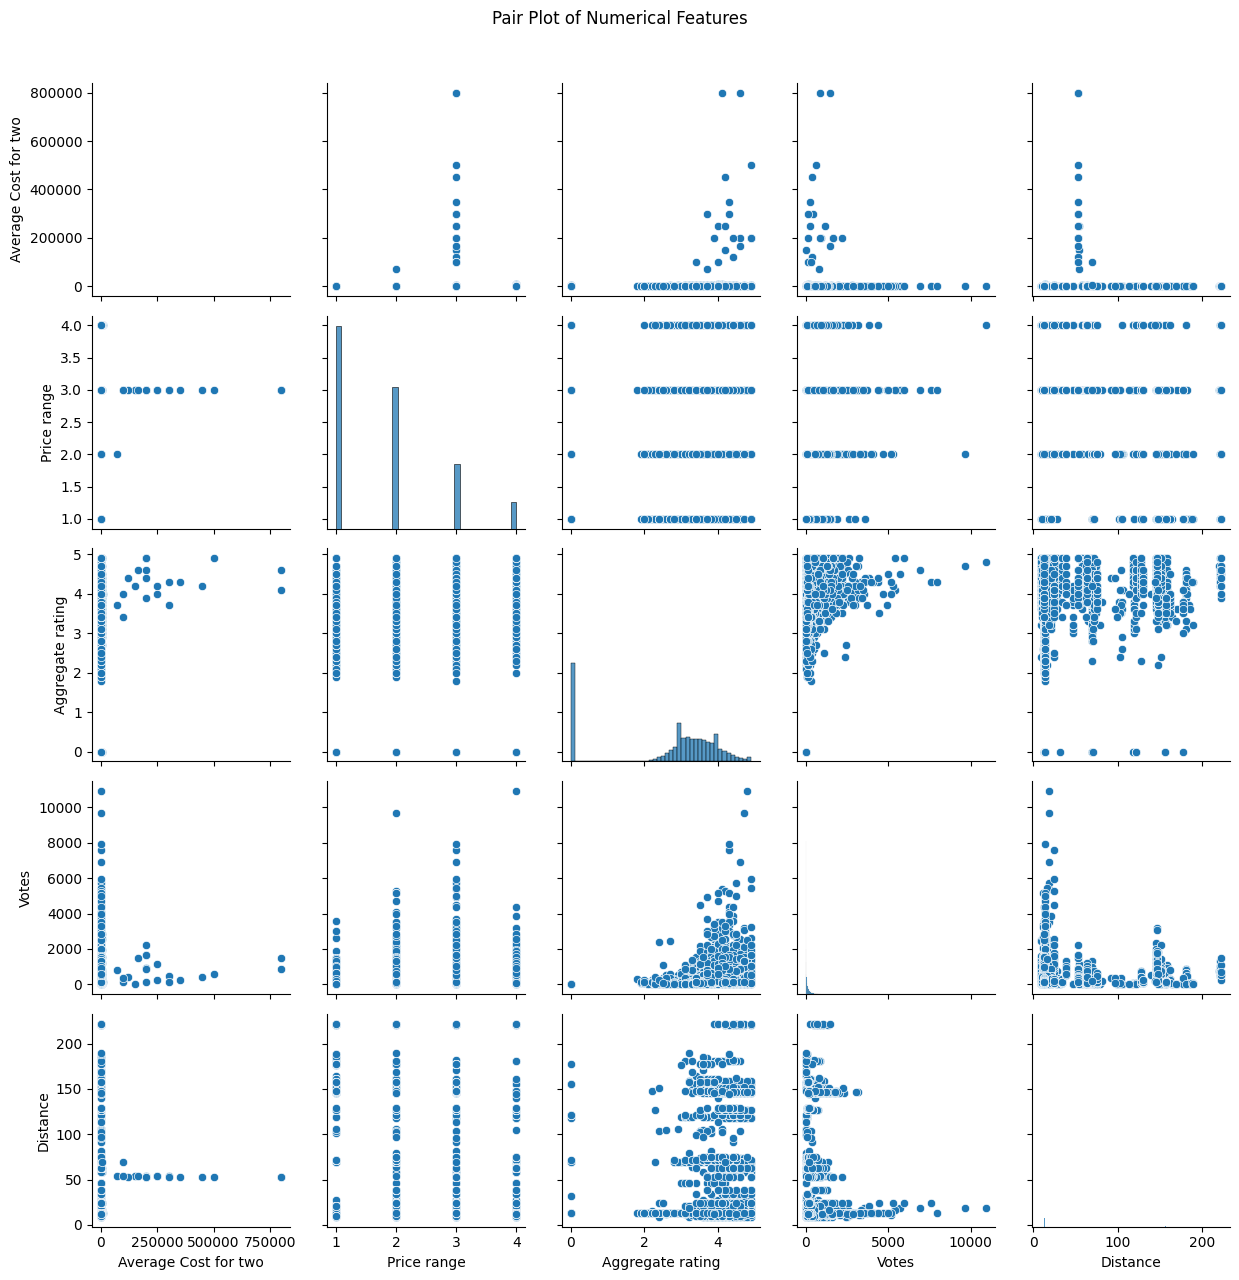

In [143]:
# Create a pair plot to visualize all bivariate relationships
sns.pairplot(df[numerical_cols])
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.tight_layout()
plt.savefig('pair_plot.png')
plt.show()

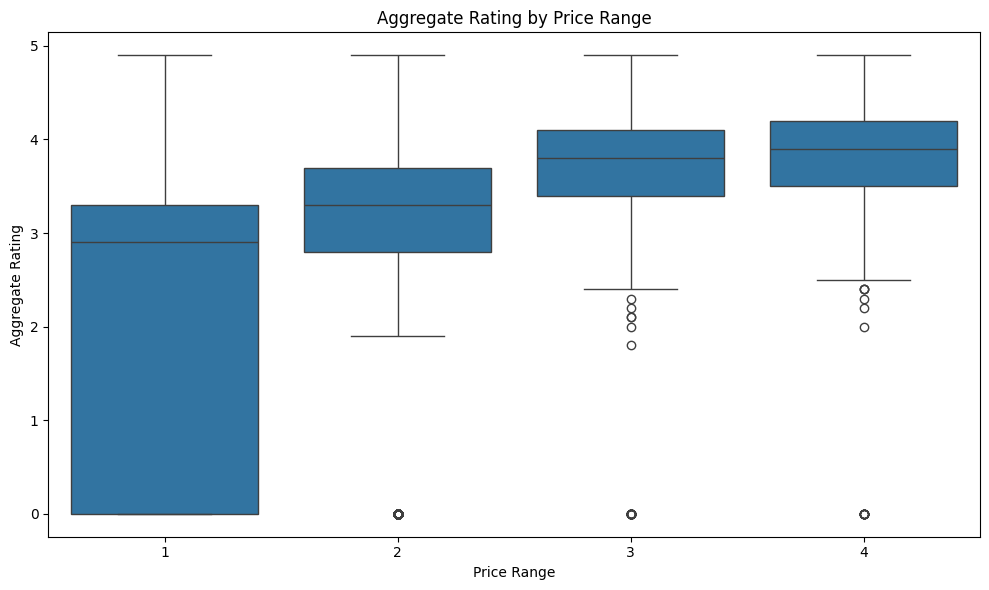

In [144]:
# Create a box plot to show the relationship between 'Price range' and 'Aggregate rating'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Price range', y='Aggregate rating', data=df)
plt.title('Aggregate Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')
plt.tight_layout()
plt.savefig('price_range_vs_rating_boxplot.png')
plt.show()

## DATA PREPROCESSING & FEATURE ENGINEERING



We do have high cardinality for few columns like

  * Restaurent Name
  * Address
  * Cuisines

So, we are extracting the length of this columns.


In [145]:
# Length of the restaurant name
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)

In [146]:
# Lenght of the address
df['Address Length'] = df['Address'].apply(len)

In [147]:
# Count of words in cuisines
df['Cuisine Count'] = df['Cuisines'].apply(lambda x: len(str(x).split(',')))

In [148]:
# Wether restaurent offers Multiple Cuisines
df['Multiple Cuisines'] = df['Cuisine Count'].apply(lambda x: 1 if x>1 else 0)

In [149]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Distance', 'Restaurant Name Length', 'Address Length',
       'Cuisine Count', 'Multiple Cuisines'],
      dtype='object')

**DROPING IRRILAVENT COLUMNS**

In [150]:
columns_to_drop = [
    'Restaurant ID', 'Restaurant Name', 'Address', 'Cuisines',
    'Locality Verbose', 'Switch to order menu',
    'Rating color', 'Rating text',
    'Locality' # Locality has high cardinality. We'll drop it to simplify.
]
df_processed = df.drop(columns=columns_to_drop)

**COLUMN GROUPS FOR PRE-PROCESSING**

In [151]:
# Columns for One-Hot Encoding (Nominal)
nominal_cols = ['Country Code', 'City', 'Currency']

In [152]:
# Columns for Label Encoding (Binary)
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']

In [153]:
# Columns for Scaling (Numerical)
numerical_cols = [
    'Longitude', 'Latitude', 'Average Cost for two',
    'Price range', 'Aggregate rating', 'Votes', 'Distance',
    'Restaurant Name Length', 'Address Length', 'Cuisine Count',
    'Multiple Cuisines'
]

## ENCODING AND SCALING

In [154]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [155]:
#Prepare Label encoding for the binary columns
for col in binary_cols:
  le = LabelEncoder()
  df_processed[col] = le.fit_transform(df_processed[col])

In [156]:
# Creating a prepreocessing pipeline
# This is a robust way to handle transformation in structured manner
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('scaler', StandardScaler(), numerical_cols)
    ],
    remainder = 'passthrough'
)

In [157]:
#Apply the preprocessing pipeline to your df
# This will create a new Numpy array with all preprocessed features
X_preprocessed = preprocessor.fit_transform(df_processed)

In [158]:
# you can get the columns from the OheHotEncoder to reconstruct the Dataframe
onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
all_feature_names = list(onehot_feature_names) + numerical_cols + binary_cols
# The reminder will be added at the end, but we already handled all colmns
#So we can ignore 'reminder' here.

In [159]:
print("Shape of preprocessed data:", X_preprocessed.shape)
print("\nFirst row of preprocessed data:")
print(X_preprocessed)

Shape of preprocessed data: (9551, 182)

First row of preprocessed data:
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [160]:
print("\nFirst S valiues of'Multiple Cuisines' after prepressing:")
print(df_processed['Multiple Cuisines'].head())


First S valiues of'Multiple Cuisines' after prepressing:
0    1
1    0
2    1
3    1
4    1
Name: Multiple Cuisines, dtype: int64


In [161]:
df_processed

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes,Distance,Restaurant Name Length,Address Length,Cuisine Count,Multiple Cuisines
0,162,Makati City,121.027535,14.565443,1100,Botswana Pula(P),1,0,0,3,4.8,314,58.009994,16,71,3,1
1,162,Makati City,121.014101,14.553708,1200,Botswana Pula(P),1,0,0,3,4.5,591,57.999102,16,67,1,0
2,162,Mandaluyong City,121.056831,14.581404,4000,Botswana Pula(P),1,0,0,4,4.4,270,58.035628,22,56,4,1
3,162,Mandaluyong City,121.056475,14.585318,1500,Botswana Pula(P),0,0,0,4,4.9,365,58.034519,4,70,2,1
4,162,Mandaluyong City,121.057508,14.584450,1500,Botswana Pula(P),1,0,0,4,4.8,229,58.035700,11,64,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,208,��stanbul,28.977392,41.022793,80,Turkish Lira(TL),0,0,0,3,4.1,788,38.282448,11,103,1,0
9547,208,��stanbul,29.041297,41.009847,105,Turkish Lira(TL),0,0,0,3,4.2,1034,38.218645,12,77,3,1
9548,208,��stanbul,29.034640,41.055817,170,Turkish Lira(TL),0,0,0,4,3.7,661,38.243006,5,73,2,1
9549,208,��stanbul,29.036019,41.057979,120,Turkish Lira(TL),0,0,0,4,4.0,901,38.242600,11,75,1,0


In [174]:
df_processed['Has_Table_Booking_and_Online_Delivery'] = df_processed['Has Table booking'] * df_processed['Has Online delivery']

In [175]:
df_processed.columns

Index(['Country Code', 'City', 'Longitude', 'Latitude', 'Average Cost for two',
       'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Aggregate rating', 'Votes',
       'Distance', 'Restaurant Name Length', 'Address Length', 'Cuisine Count',
       'Multiple Cuisines', 'Has_Table_Booking_and_Oniine_Delivery',
       'Has_Table_Booking_and_Online_Delivery'],
      dtype='object')

In [176]:
df_processed.head()

,Country Code,City,Longitude,Latitude,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes,Distance,Restaurant Name Length,Address Length,Cuisine Count,Multiple Cuisines,Has_Table_Booking_and_Oniine_Delivery,Has_Table_Booking_and_Online_Delivery
0,162,Makati City,121.027535,14.565443,1100,Botswana Pula(P),1,0,0,3,4.8,314,58.009994,16,71,3,1,0,0
1,162,Makati City,121.014101,14.553708,1200,Botswana Pula(P),1,0,0,3,4.5,591,57.999102,16,67,1,0,0,0
2,162,Mandaluyong City,121.056831,14.581404,4000,Botswana Pula(P),1,0,0,4,4.4,270,58.035628,22,56,4,1,0,0
3,162,Mandaluyong City,121.056475,14.585318,1500,Botswana Pula(P),0,0,0,4,4.9,365,58.034519,4,70,2,1,0,0
4,162,Mandaluyong City,121.057508,14.584450,1500,Botswana Pula(P),1,0,0,4,4.8,229,58.035700,11,64,2,1,0,0


##  MODEL BUILDING

In [177]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [178]:
X = df_processed.drop(columns = ['Aggregate rating'])
y = df_processed['Aggregate rating']

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [180]:
numerical_features = [
    'Longitude', 'Latitude', 'Average Cost for two', 'Votes', 'Distance',
    'Price range', 'Restaurant Name Length', 'Address Length',
    'Cuisine Count', 'Multiple Cuisines', 'Has Table booking',
    'Has Online delivery', 'Is delivering now', 'Has_Table_Booking_and_Online_Delivery'
]
categorical_features = ['Country Code', 'City', 'Currency']

In [181]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

Model Tuning and Evaluation Loop

In [182]:
# Define the models within pipelines
pipelines = {
    'RandomForest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
    'GradientBoosting': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42))]),
    'Ridge': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(random_state=42))])
}

In [183]:
# Define hyperparameter grids for each model
param_grids = {
    'RandomForest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [10, None],
    },
    'GradientBoosting': {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.1, 0.05],
    },
    'Ridge': {
        'regressor__alpha': [0.1, 1.0, 10.0]
    }
}

Initialize Result Storage and Loop Through Models

In [184]:
results = {}
best_model_overall = None
best_score = -np.inf


In [185]:
# Assume X_train, X_test, y_train, y_test are defined
for name in pipelines.keys():
    print(f"--- Starting GridSearchCV for {name} ---")

    # This part performs the hyperparameter tuning
    grid_search = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        scoring='r2',
        cv=3,
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # This part evaluates the best-tuned model
    tuned_model = grid_search.best_estimator_
    y_pred = tuned_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Store the results
    results[name] = {
        'Best Parameters': grid_search.best_params_,
        'R2 Score': r2,
        'Mean Squared Error': mse
    }

    # Print the individual results
    print(f"Finished {name}. Test Set Results:")
    print(f"  Best Parameters: {grid_search.best_params_}")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  Mean Squared Error: {mse:.4f}\n")

    # Update the best model tracker
    if r2 > best_score:
        best_score = r2
        best_model_overall = tuned_model

--- Starting GridSearchCV for RandomForest ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Finished RandomForest. Test Set Results:
  Best Parameters: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
  R2 Score: 0.9594
  Mean Squared Error: 0.0925

--- Starting GridSearchCV for GradientBoosting ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Finished GradientBoosting. Test Set Results:
  Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__n_estimators': 200}
  R2 Score: 0.9585
  Mean Squared Error: 0.0945

--- Starting GridSearchCV for Ridge ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Finished Ridge. Test Set Results:
  Best Parameters: {'regressor__alpha': 1.0}
  R2 Score: 0.3629
  Mean Squared Error: 1.4501



**DISPLAY FINAL RESULT**

In [186]:
results_df = pd.DataFrame(results).T.sort_values(by='R2 Score', ascending=False)
print("--- Final Model Comparison ---")
print(results_df)

--- Final Model Comparison ---
                                                    Best Parameters  R2 Score  \
RandomForest      {'regressor__max_depth': None, 'regressor__n_e...  0.959361   
GradientBoosting  {'regressor__learning_rate': 0.1, 'regressor__...    0.9585   
Ridge                                     {'regressor__alpha': 1.0}  0.362882   

                 Mean Squared Error  
RandomForest               0.092498  
GradientBoosting           0.094458  
Ridge                       1.45015  


In [187]:
if best_model_overall:
    model_name = results_df.index[0]
    joblib.dump(best_model_overall, f'best_tuned_restaurant_rating_model_{model_name}.pkl')
    print(f"\nOverall best model ({model_name}) pipeline saved to 'best_tuned_restaurant_rating_model_{model_name}.pkl'")


Overall best model (RandomForest) pipeline saved to 'best_tuned_restaurant_rating_model_RandomForest.pkl'
